In [1]:
%%capture
!pip install pandas matplotlib

In [65]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# Há quatro tipos princípais de análise de dados

# Análise de dados descritiva
# Análise de dados diagnóstica
# Análise preditiva
# Análise prescritiva

In [8]:
df = pd.read_csv('/content/Motor_Vehicle_Collisions_-_Crashes.csv', )

/tmp/ipykernel_750/2241992599.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Motor_Vehicle_Collisions_-_Crashes.csv', )


In [9]:
df.head(2)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN


In [ ]:
# AGEMC

# ASK
# GET
# MODEL
# EXPLORER
# COMUNICATE

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243397 entries, 0 to 2243396
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

In [11]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [13]:
df['VEHICLE TYPE CODE 1'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2243397 entries, 0 to 2243396
Series name: VEHICLE TYPE CODE 1
Non-Null Count    Dtype 
--------------    ----- 
2226761 non-null  object
dtypes: object(1)
memory usage: 17.1+ MB


In [14]:
df['VEHICLE TYPE CODE 1'].value_counts()

,count
VEHICLE TYPE CODE 1,
Sedan,652335
Station Wagon/Sport Utility Vehicle,510429
PASSENGER VEHICLE,416206
SPORT UTILITY / STATION WAGON,180291
Taxi,56567
...,...
SCOOTOR,1
DSNY TRUCK,1
mini van,1


In [15]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [16]:
df.head(2)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN


In [18]:
# Será que existe algum dia da semana que tem um trânsito mais turbulento?

df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], format= "%m/%d/%Y")
df['dia semana acidente'] = df['CRASH DATE'].dt.day_name()

In [22]:
contagem_dias_semana = df['dia semana acidente'].value_counts()
contagem_dias_semana = contagem_dias_semana.reset_index()

In [23]:
contagem_dias_semana.head()

,dia semana acidente,count
0,Friday,356876
1,Thursday,334809
2,Tuesday,329694
3,Wednesday,327210
4,Monday,320332


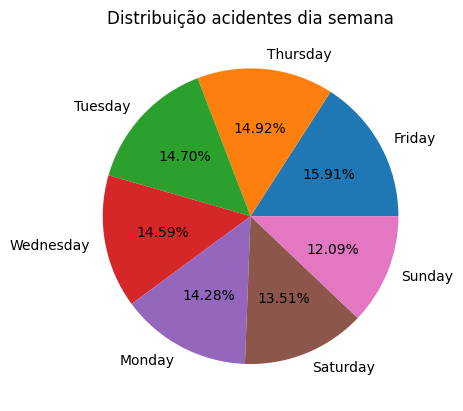

In [67]:
from matplotlib import style
style.use("default")

plt.pie(contagem_dias_semana['count'],
        labels= contagem_dias_semana['dia semana acidente'],
        autopct= "%.2f%%")

plt.title("Distribuição acidentes dia semana")
plt.show()

In [35]:
# Quais os meses do ano com mais registros de acidentes

distribuicao_mensal = df['CRASH DATE'].dt.month_name().value_counts()
distribuicao_mensal = distribuicao_mensal.reset_index()

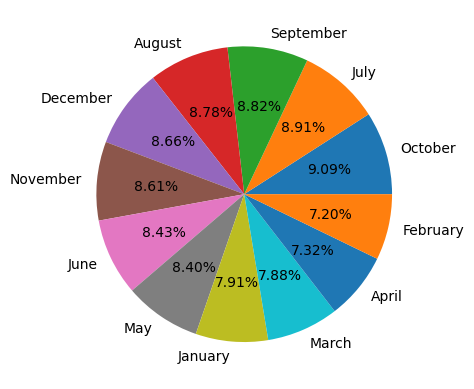

In [68]:
plt.pie(distribuicao_mensal['count'],
        labels= distribuicao_mensal['CRASH DATE'],
        autopct= "%.2f%%")

plt.show()

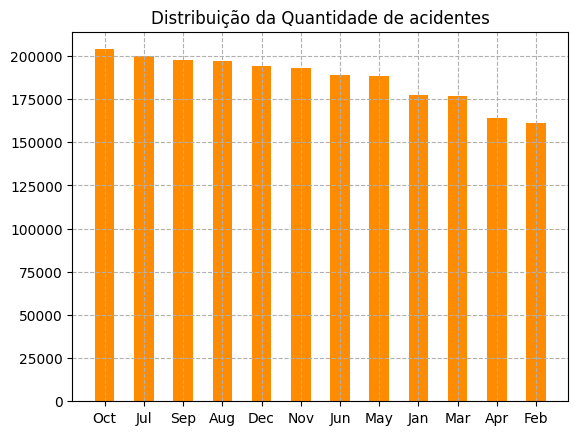

In [71]:
# Um gráfico de barras é melhor nesta situação

plt.bar([nome[: 3] for nome in distribuicao_mensal["CRASH DATE"]],
        distribuicao_mensal["count"],
        width= 0.5,
        color= 'darkorange')

plt.grid(linestyle= '--',
         alpha= 1)


plt.title("Distribuição da Quantidade de Acidentes")

plt.show()

In [ ]:
# Quais os horários mais propricios a acidentes?


In [ ]:
# Perguntas?

# Quais os tipos de dados que mais se envolvem em assidentes em NY?